# Healthcare Patient Clustering by Clinical Indicators

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
# read the csv file into a dataframe
path = "data/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 253680
Columns: 22


In [4]:
print(list(df.columns))

['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [5]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 2. Understand and Explore Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [8]:
# how many patients fall in each diabetes class
labels = ["No Diabetes", "Prediabetes", "Diabetes"]
counts = df["Diabetes_012"].value_counts().sort_index()
print(counts)

Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


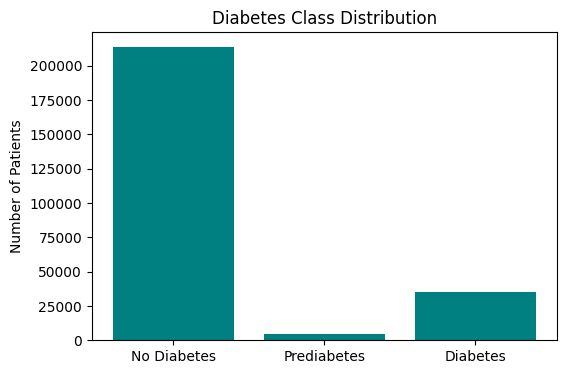

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color="teal")
plt.ylabel("Number of Patients")
plt.title("Diabetes Class Distribution")
plt.show()

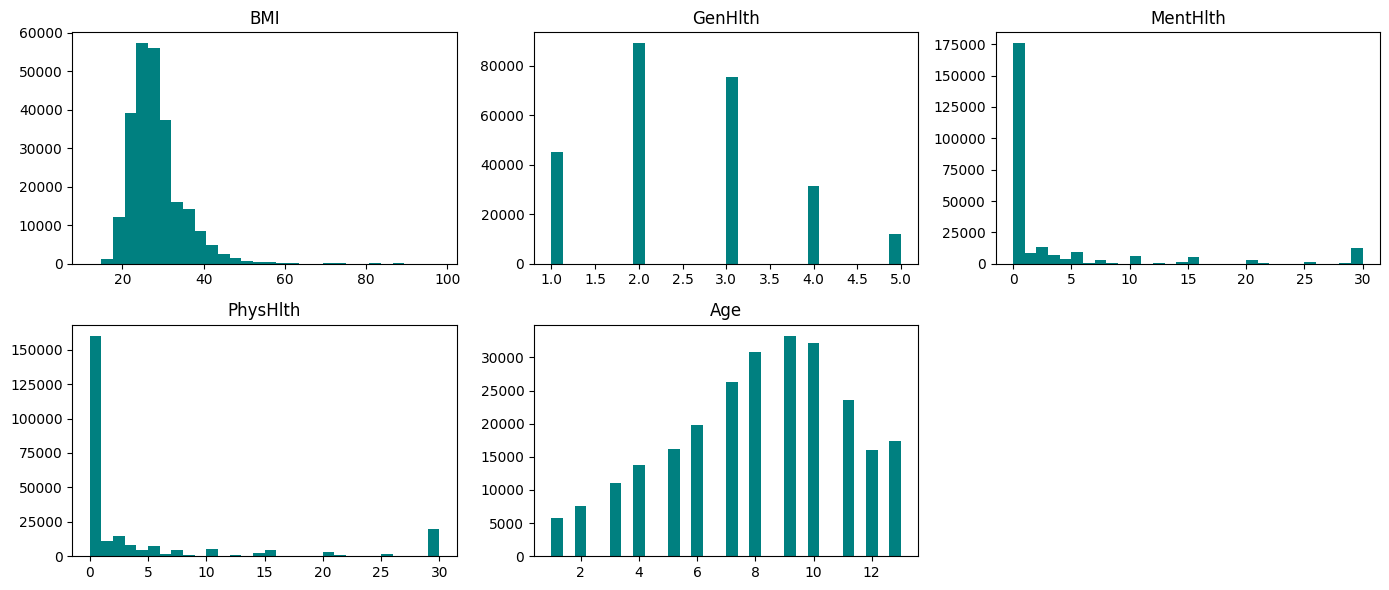

In [10]:
# histograms to see the shape of the numeric columns
num_cols = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age"]

plt.figure(figsize=(14, 6))
for i in range(len(num_cols)):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[num_cols[i]], bins=30, color="teal")
    plt.title(num_cols[i])
plt.tight_layout()
plt.show()

In [11]:
# these columns are 0 or 1, so the mean is the percent of patients who have it
bin_cols = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
            "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
            "NoDocbcCost", "DiffWalk", "Sex"]

prevalence = []
for col in bin_cols:
    prevalence.append(df[col].mean() * 100)
    print(col, ":", round(df[col].mean() * 100, 2), "%")

HighBP : 42.9 %
HighChol : 42.41 %
CholCheck : 96.27 %
Smoker : 44.32 %
Stroke : 4.06 %
HeartDiseaseorAttack : 9.42 %
PhysActivity : 75.65 %
Fruits : 63.43 %
Veggies : 81.14 %
HvyAlcoholConsump : 5.62 %
AnyHealthcare : 95.11 %
NoDocbcCost : 8.42 %
DiffWalk : 16.82 %
Sex : 44.03 %


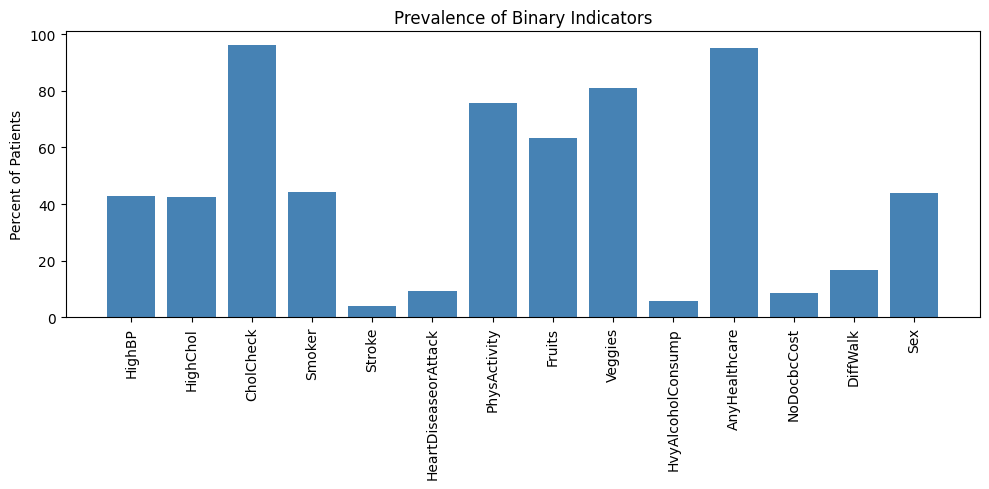

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(bin_cols, prevalence, color="steelblue")
plt.xticks(rotation=90)
plt.ylabel("Percent of Patients")
plt.title("Prevalence of Binary Indicators")
plt.tight_layout()
plt.show()

In [13]:
# which columns move together with diabetes
correlation = df.corr()["Diabetes_012"]
correlation = correlation.drop("Diabetes_012")
print(correlation.sort_values(ascending=False).round(3))

GenHlth                 0.303
HighBP                  0.272
BMI                     0.224
DiffWalk                0.224
HighChol                0.209
Age                     0.185
HeartDiseaseorAttack    0.180
PhysHlth                0.176
Stroke                  0.107
MentHlth                0.074
CholCheck               0.068
Smoker                  0.063
NoDocbcCost             0.035
Sex                     0.031
AnyHealthcare           0.015
Fruits                 -0.042
HvyAlcoholConsump      -0.058
Veggies                -0.059
PhysActivity           -0.122
Education              -0.131
Income                 -0.171
Name: Diabetes_012, dtype: float64


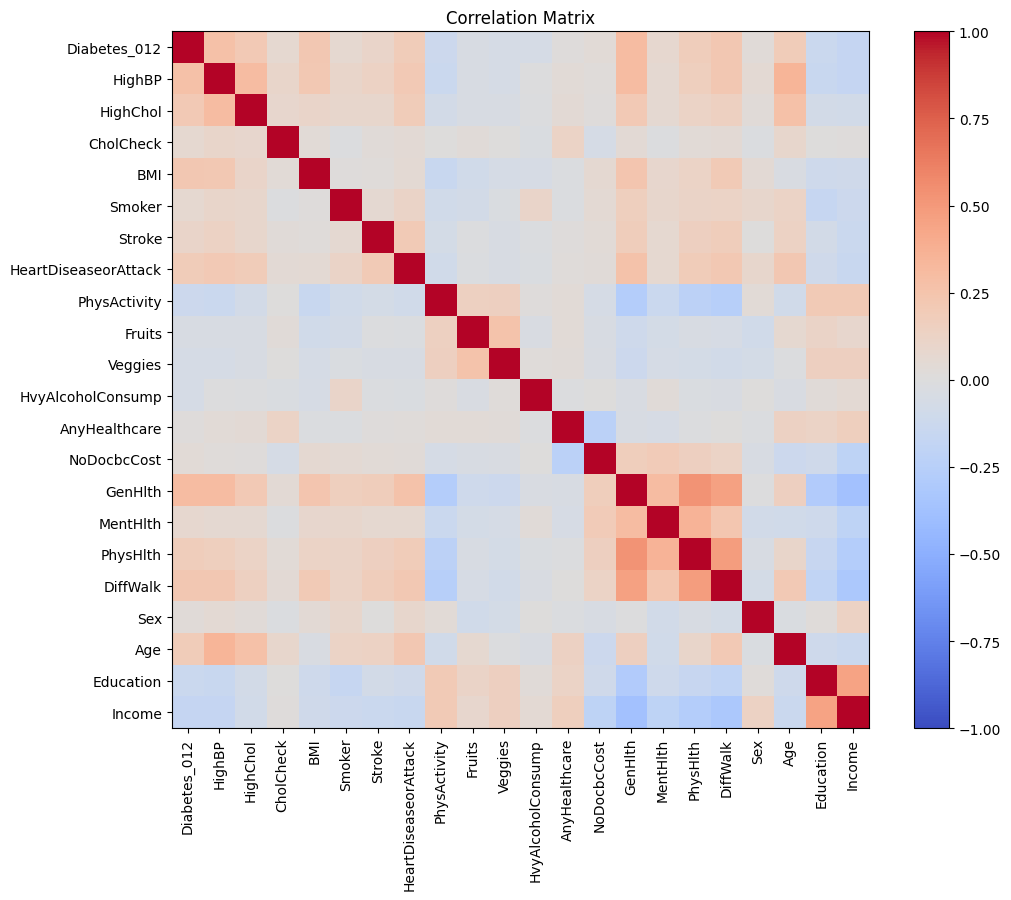

In [14]:
plt.figure(figsize=(11, 9))
plt.imshow(df.corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [15]:
# check for missing values
print(df.isnull().sum())
print("Total missing:", df.isnull().sum().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
Total missing: 0


In [16]:
# the same survey answers repeat many times, so remove the copies
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Rows now:", len(df))

Duplicate rows: 23899
Rows now: 229781


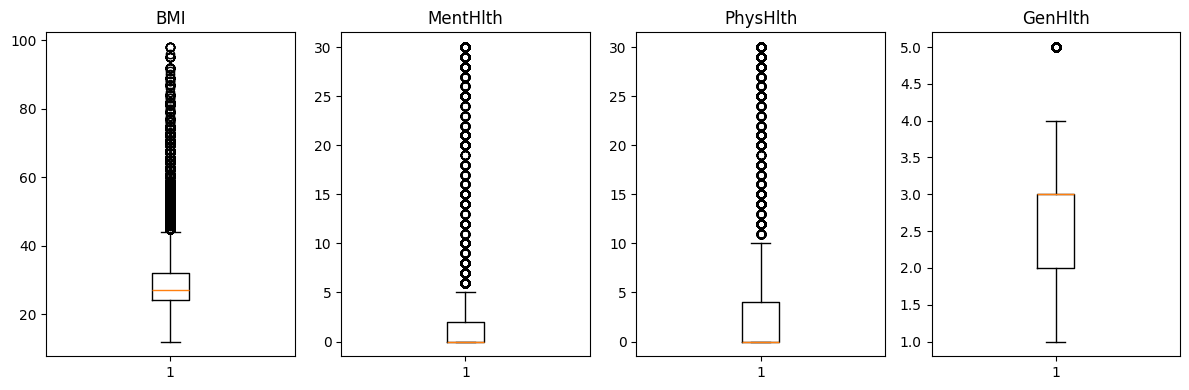

In [17]:
# boxplots to look for outliers
box_cols = ["BMI", "MentHlth", "PhysHlth", "GenHlth"]

plt.figure(figsize=(12, 4))
for i in range(len(box_cols)):
    plt.subplot(1, 4, i + 1)
    plt.boxplot(df[box_cols[i]])
    plt.title(box_cols[i])
plt.tight_layout()
plt.show()

In [18]:
print("BMI minimum:", df["BMI"].min())
print("BMI maximum:", df["BMI"].max())

BMI minimum: 12.0
BMI maximum: 98.0


In [19]:
# a BMI of 98 is real but it would pull the cluster centre towards it,
# so cap BMI instead of deleting the patient
low = df["BMI"].quantile(0.01)
high = df["BMI"].quantile(0.99)

df["BMI"] = df["BMI"].clip(low, high)
print("BMI capped between", low, "and", high)

BMI capped between 18.0 and 50.0


In [20]:
# hierarchical clustering and dbscan need the distance between every pair of
# patients, which is too big for 229781 rows. so take a sample of 10000 and run
# all three algorithms on the same patients, then the comparison is fair
df = df.sample(10000, random_state=42)
df = df.reset_index(drop=True)
print("Sample size:", len(df))

Sample size: 10000


## 4. Select Clinical Features

Dropped columns and the reason:

- `Diabetes_012` - target, kept aside to check the clusters later
- `Income`, `Education` - not clinical
- `AnyHealthcare`, `NoDocbcCost` - healthcare access, not health
- `Fruits`, `Veggies` - almost no correlation with the outcome
- `CholCheck` - 96 percent of patients are 1, no variance
- `Sex` - demographic, would split the clusters by gender
- `HvyAlcoholConsump` - only 6 percent are 1, k-means made it a cluster of its own

In [21]:
features = ["HighBP", "HighChol", "BMI", "Stroke", "HeartDiseaseorAttack", "GenHlth",
            "MentHlth", "PhysHlth", "DiffWalk", "Age", "Smoker", "PhysActivity"]

X = df[features]
print("Patients:", X.shape[0])
print("Features:", X.shape[1])

Patients: 10000
Features: 12


In [22]:
X.head()

,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Smoker,PhysActivity
0,0.0,1.0,33.0,0.0,1.0,3.0,20.0,21.0,1.0,12.0,1.0,1.0
1,0.0,0.0,27.0,0.0,0.0,5.0,30.0,30.0,0.0,4.0,1.0,0.0
2,1.0,0.0,20.0,0.0,0.0,2.0,0.0,0.0,0.0,11.0,0.0,1.0
3,1.0,0.0,28.0,0.0,0.0,2.0,0.0,0.0,0.0,13.0,1.0,1.0
4,0.0,0.0,18.0,0.0,0.0,5.0,30.0,30.0,1.0,6.0,1.0,0.0


In [23]:
# a feature with almost no variance cannot help in clustering
for col in features:
    print(col, ":", round(X[col].var(), 3))

HighBP : 0.247
HighChol : 0.247
BMI : 37.573
Stroke : 0.038
HeartDiseaseorAttack : 0.09
GenHlth : 1.13
MentHlth : 60.879
PhysHlth : 81.299
DiffWalk : 0.15
Age : 9.562
Smoker : 0.249
PhysActivity : 0.193


## 5. Feature Scaling

In [24]:
# BMI goes up to 50 but the 0/1 columns only to 1, so without scaling the
# distance would be decided by BMI alone
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape:", X_scaled.shape)

Shape: (10000, 12)


In [25]:
print("Mean after scaling:", round(X_scaled[:, 0].mean(), 4))
print("Std after scaling:", round(X_scaled[:, 0].std(), 4))

Mean after scaling: 0.0
Std after scaling: 1.0


## 6. Apply Three Clustering Algorithms

### 6a. K-Means with Elbow Method

In [26]:
# try different values of k and save inertia and silhouette for each one
k_values = [2, 3, 4, 5, 6, 7, 8]
inertias = []
kmeans_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    kmeans_scores.append(silhouette_score(X_scaled, labels))
    print("K =", k, " Inertia =", round(model.inertia_),
          " Silhouette =", round(kmeans_scores[-1], 4))

K = 2  Inertia = 100208  Silhouette = 0.2748


K = 3  Inertia = 90866  Silhouette = 0.1418


K = 4  Inertia = 82279  Silhouette = 0.1539


K = 5  Inertia = 77385  Silhouette = 0.1304


K = 6  Inertia = 72025  Silhouette = 0.131


K = 7  Inertia = 67697  Silhouette = 0.1462


K = 8  Inertia = 64373  Silhouette = 0.1404


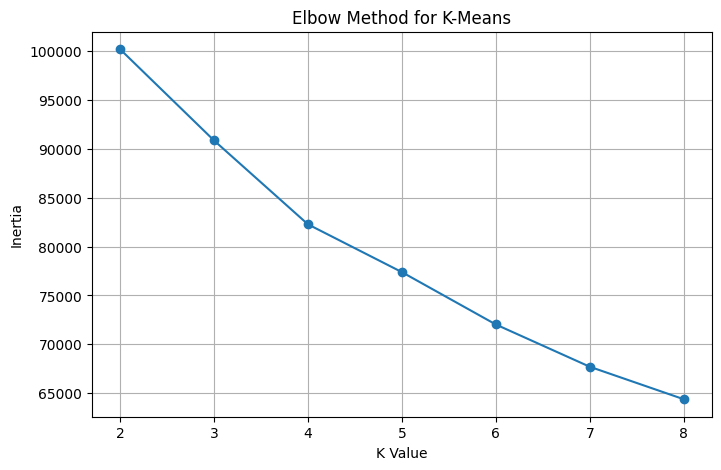

In [27]:
# the elbow is the k where the curve stops falling steeply
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("K Value")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

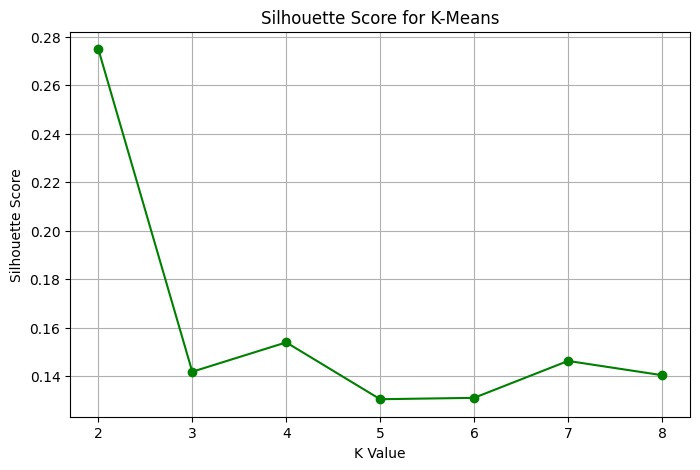

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, kmeans_scores, marker='o', color="green")
plt.xlabel("K Value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [29]:
# inertia bends at k = 3. k = 2 scores better but it only gives healthy and
# unhealthy with no middle group, so k = 3 is chosen
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

In [30]:
print("Cluster sizes:", np.bincount(kmeans_labels))
print("Silhouette Score:", round(kmeans_silhouette, 4))

Cluster sizes: [1721 3377 4902]
Silhouette Score: 0.1418


### 6b. Hierarchical Clustering with Dendrogram

In [31]:
# ward linkage joins the two clusters that increase the spread the least
linked = linkage(X_scaled, method="ward")

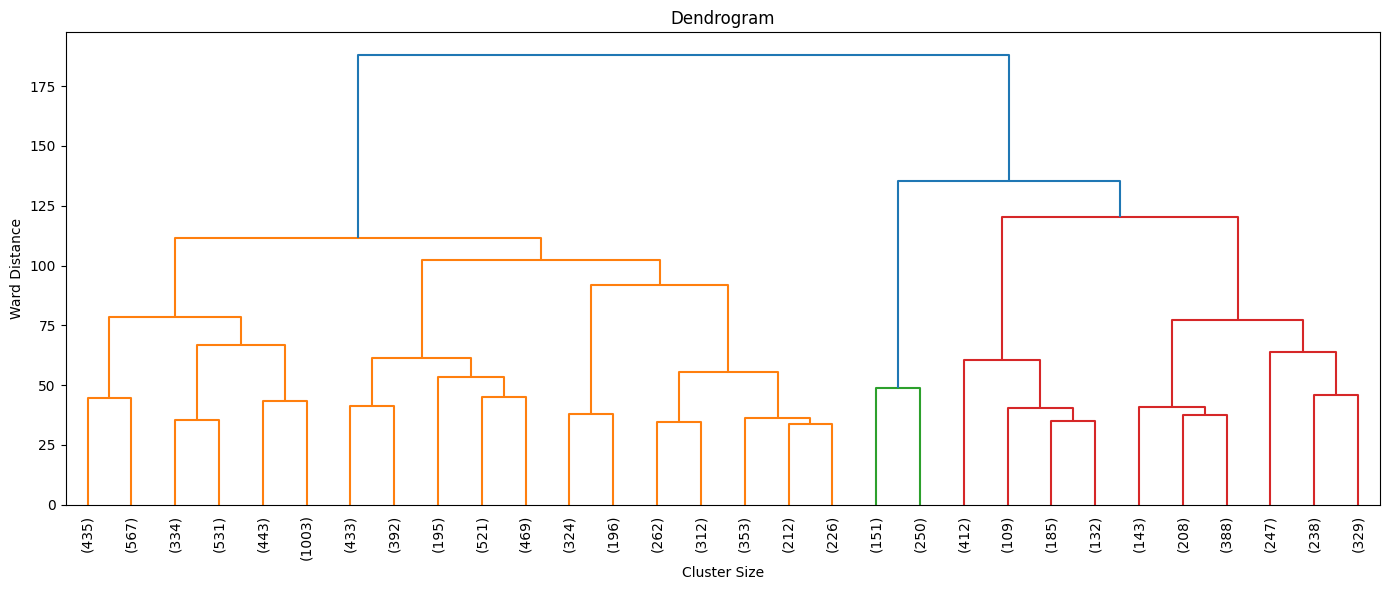

In [32]:
plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.xlabel("Cluster Size")
plt.ylabel("Ward Distance")
plt.title("Dendrogram")
plt.tight_layout()
plt.show()

In [33]:
# silhouette of hierarchical clustering for the same k values
hier_scores = []

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    hier_scores.append(silhouette_score(X_scaled, labels))
    print("K =", k, " Silhouette =", round(hier_scores[-1], 4))

K = 2  Silhouette = 0.2495


K = 3  Silhouette = 0.2486


K = 4  Silhouette = 0.2557


K = 5  Silhouette = 0.1236


K = 6  Silhouette = 0.13


K = 7  Silhouette = 0.147


K = 8  Silhouette = 0.1272


In [34]:
# the longest gap in the dendrogram splits the tree into 3 branches
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)
hier_silhouette = silhouette_score(X_scaled, hier_labels)

In [35]:
print("Cluster sizes:", np.bincount(hier_labels))
print("Silhouette Score:", round(hier_silhouette, 4))

Cluster sizes: [2391 7208  401]
Silhouette Score: 0.2486


### 6c. DBSCAN with K-Distance Graph

In [36]:
# rule of thumb: min_samples = 2 * number of features
min_samples = 2 * len(features)
print("min_samples =", min_samples)

min_samples = 24


In [37]:
# distance of every point to its 24th nearest neighbour, sorted
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
k_distance = np.sort(distances[:, -1])

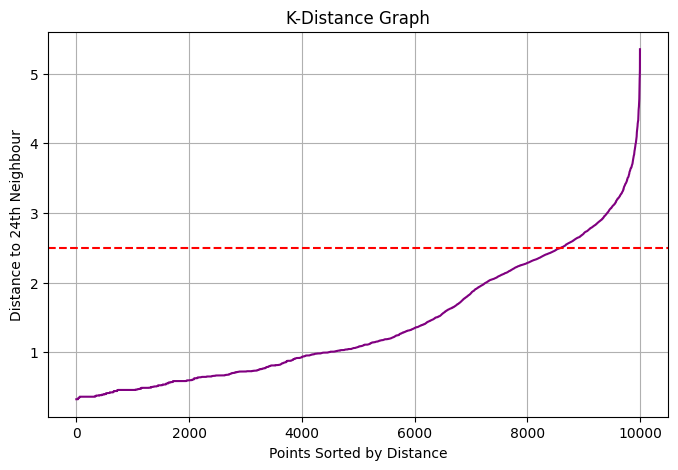

In [38]:
# the bend in this graph is the value of eps
plt.figure(figsize=(8, 5))
plt.plot(k_distance, color="purple")
plt.axhline(2.5, color="red", linestyle="--")
plt.xlabel("Points Sorted by Distance")
plt.ylabel("Distance to 24th Neighbour")
plt.title("K-Distance Graph")
plt.grid(True)
plt.show()

In [39]:
# check a few values around the bend before fixing eps
for e in [1.5, 2.0, 2.5, 3.0, 3.5]:
    labels = DBSCAN(eps=e, min_samples=min_samples).fit_predict(X_scaled)
    print("eps =", e,
          " Clusters =", len(set(labels)) - 1,
          " Noise =", list(labels).count(-1),
          " Silhouette =", round(silhouette_score(X_scaled, labels), 4))

eps = 1.5  Clusters = 27  Noise = 2705  Silhouette = 0.1271


eps = 2.0  Clusters = 34  Noise = 1852  Silhouette = 0.154


eps = 2.5  Clusters = 5  Noise = 566  Silhouette = 0.2264


eps = 3.0  Clusters = 5  Noise = 153  Silhouette = 0.2665


eps = 3.5  Clusters = 2  Noise = 40  Silhouette = 0.3775


In [40]:
# below 2.5 dbscan makes many tiny clusters, above it everything becomes one
eps = 2.5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)

In [41]:
n_dbscan_clusters = len(set(dbscan_labels)) - 1
n_noise = list(dbscan_labels).count(-1)

print("Clusters found:", n_dbscan_clusters)
print("Noise points:", n_noise)
print("Silhouette Score:", round(dbscan_silhouette, 4))

Clusters found: 5
Noise points: 566
Silhouette Score: 0.2264


In [42]:
# label -1 means noise
print(pd.Series(dbscan_labels).value_counts().sort_index())

-1     566
 0    7389
 1     130
 2    1233
 3     456
 4     226
Name: count, dtype: int64


## 7. Evaluate All Three Models

Silhouette score tells how close a patient is to its own cluster compared to the
nearest other cluster. It goes from -1 to 1 and higher is better.

In [43]:
print("K-Means      :", round(kmeans_silhouette, 4))
print("Hierarchical :", round(hier_silhouette, 4))
print("DBSCAN       :", round(dbscan_silhouette, 4))

K-Means      : 0.1418
Hierarchical : 0.2486
DBSCAN       : 0.2264


## 8. Compare Models

In [44]:
# percent of patients sitting in the biggest cluster of each model
biggest = []

for labels in [kmeans_labels, hier_labels, dbscan_labels]:
    sizes = pd.Series(labels)
    sizes = sizes[sizes != -1].value_counts()
    biggest.append(round(sizes.max() / len(labels) * 100, 1))

print(biggest)

[np.float64(49.0), np.float64(72.1), np.float64(73.9)]


In [45]:
names = ["K-Means", "Hierarchical", "DBSCAN"]
all_scores = [kmeans_silhouette, hier_silhouette, dbscan_silhouette]

comparison = pd.DataFrame()
comparison["Algorithm"] = names
comparison["Clusters"] = [best_k, 3, n_dbscan_clusters]
comparison["Silhouette"] = np.round(all_scores, 4)
comparison["Largest cluster %"] = biggest
comparison["Noise points"] = [0, 0, n_noise]
comparison

,Algorithm,Clusters,Silhouette,Largest cluster %,Noise points
0,K-Means,3,0.1418,49.0,0
1,Hierarchical,3,0.2486,72.1,0
2,DBSCAN,5,0.2264,73.9,566


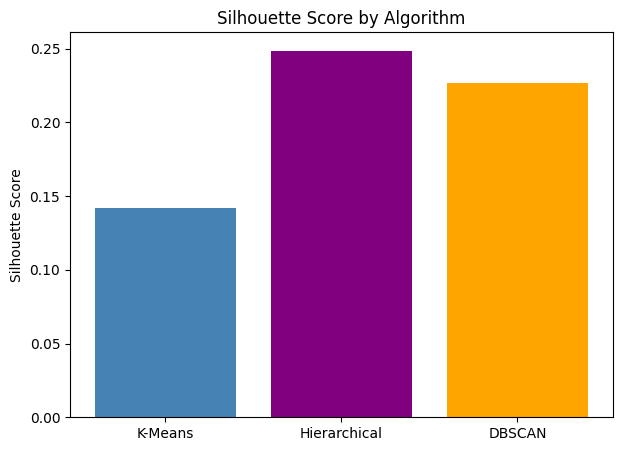

In [46]:
plt.figure(figsize=(7, 5))
plt.bar(names, all_scores, color=["steelblue", "purple", "orange"])
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Algorithm")
plt.show()

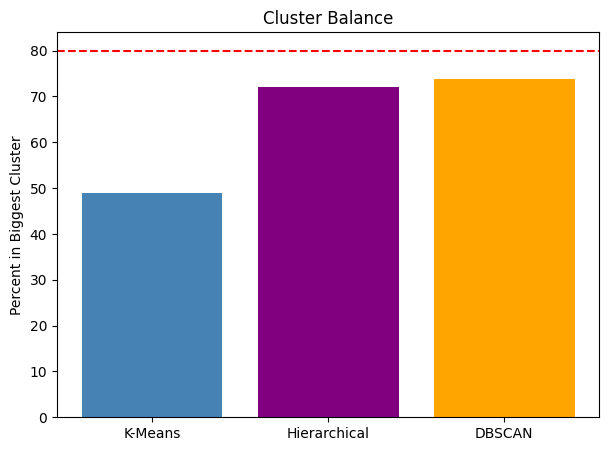

In [47]:
plt.figure(figsize=(7, 5))
plt.bar(names, biggest, color=["steelblue", "purple", "orange"])
plt.axhline(80, color="red", linestyle="--")
plt.ylabel("Percent in Biggest Cluster")
plt.title("Cluster Balance")
plt.show()

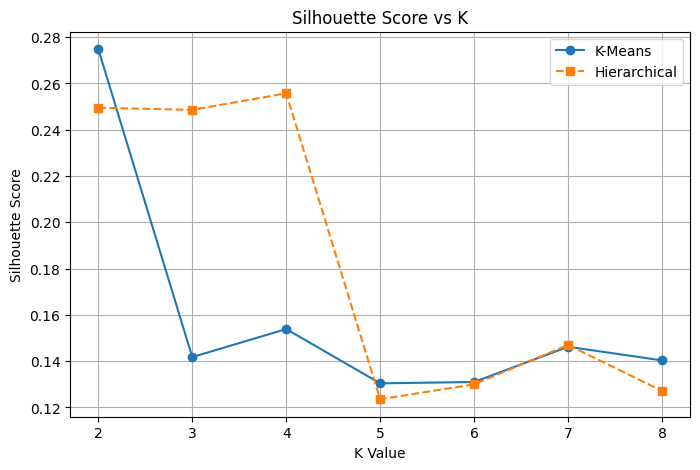

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, kmeans_scores, marker='o', label="K-Means")
plt.plot(k_values, hier_scores, marker='s', linestyle="--", label="Hierarchical")
plt.xlabel("K Value")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [49]:
scores_table = pd.DataFrame()
scores_table["k"] = k_values
scores_table["kmeans_silhouette"] = np.round(kmeans_scores, 4)
scores_table["hier_silhouette"] = np.round(hier_scores, 4)
scores_table = scores_table.set_index("k")
scores_table

,kmeans_silhouette,hier_silhouette
k,,
2,0.2748,0.2495
3,0.1418,0.2486
4,0.1539,0.2557
5,0.1304,0.1236
6,0.1310,0.1300
7,0.1462,0.1470
8,0.1404,0.1272


## 9. Select Best Clustering Model

**Best model: K-Means with k = 3.**

The score alone is not enough, the cluster sizes matter too.

1. Hierarchical and DBSCAN score higher, but both put about three fourths of the
   patients in one single cluster, so their groups are not useful.
2. DBSCAN also marks 566 patients as noise, because health risk is a continuous
   range and not separated dense groups.
3. K-Means gives three balanced groups.
4. K-Means stores cluster centres, so a new patient can be assigned later.

In [50]:
# save the k-means label of every patient back into the dataframe
df["Cluster"] = kmeans_labels
print(df["Cluster"].value_counts().sort_index())

Cluster
0    1721
1    3377
2    4902
Name: count, dtype: int64


## 10. Visualize Clusters

In [51]:
# pca brings the 12 features down to 2 so the clusters can be plotted
pca = PCA(n_components=2, random_state=42)
points = pca.fit_transform(X_scaled)
centers = pca.transform(kmeans.cluster_centers_)

In [52]:
print("Variance by PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Variance by PC2:", round(pca.explained_variance_ratio_[1], 4))

Variance by PC1: 0.2372
Variance by PC2: 0.1216


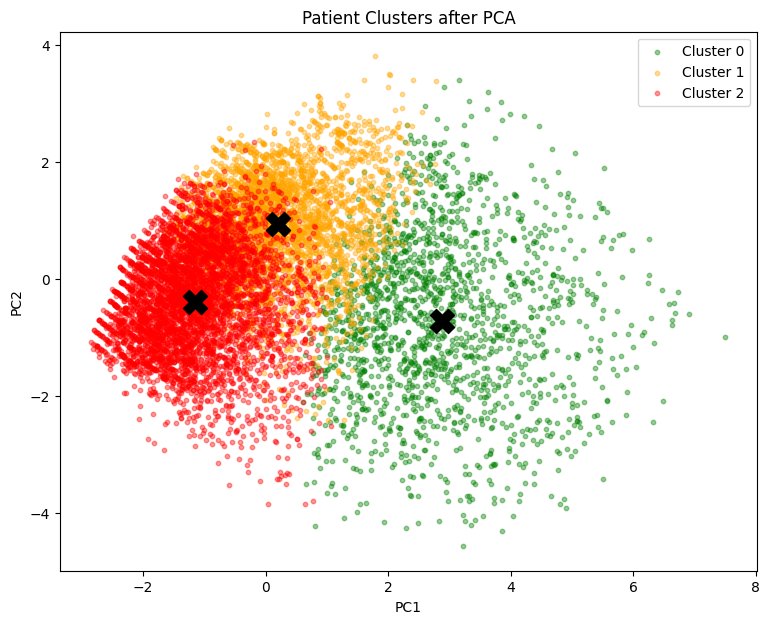

In [53]:
colors = ["green", "orange", "red"]

plt.figure(figsize=(9, 7))
for c in range(best_k):
    plt.scatter(points[df["Cluster"] == c, 0], points[df["Cluster"] == c, 1],
                s=10, alpha=0.4, color=colors[c], label="Cluster " + str(c))
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=300, color="black")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Patient Clusters after PCA")
plt.legend()
plt.show()

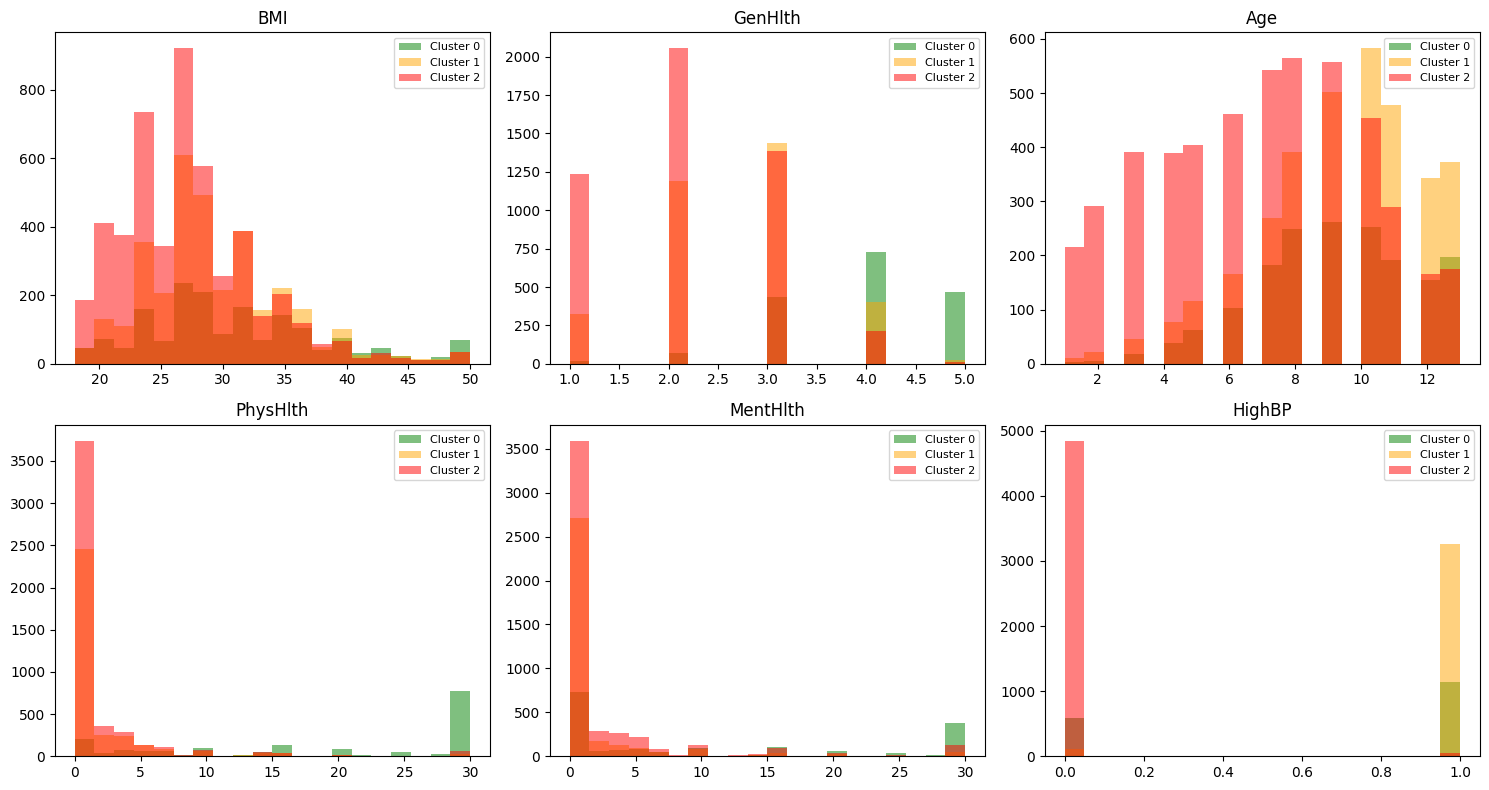

In [54]:
# compare the clusters on one feature at a time
plot_cols = ["BMI", "GenHlth", "Age", "PhysHlth", "MentHlth", "HighBP"]

plt.figure(figsize=(15, 8))
for i in range(len(plot_cols)):
    plt.subplot(2, 3, i + 1)
    for c in range(best_k):
        plt.hist(df[df["Cluster"] == c][plot_cols[i]], bins=20, alpha=0.5,
                 color=colors[c], label="Cluster " + str(c))
    plt.title(plot_cols[i])
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. Profile and Interpret Patient Clusters

In [55]:
# average value of every feature inside each cluster
profile = df.groupby("Cluster")[features].mean().round(3)
profile["n_patients"] = df["Cluster"].value_counts().sort_index()
profile.T

Cluster,0,1,2
HighBP,0.662,0.967,0.011
HighChol,0.636,0.571,0.289
BMI,31.116,29.312,27.155
Stroke,0.132,0.037,0.010
HeartDiseaseorAttack,0.309,0.114,0.018
GenHlth,3.908,2.589,2.126
MentHlth,10.582,1.654,2.393
PhysHlth,18.818,1.765,1.623
DiffWalk,0.783,0.092,0.036
Age,9.202,9.378,6.860


In [56]:
# same table as z-score, so a positive number means the cluster is above the
# population average on that feature
profile_z = df.groupby("Cluster")[features].mean()
profile_z = (profile_z - X.mean()) / X.std()
profile_z = profile_z.round(2)
profile_z

,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Smoker,PhysActivity
Cluster,,,,,,,,,,,,
0,0.43,0.39,0.42,0.47,0.69,1.24,0.90,1.57,1.55,0.35,0.30,-0.62
1,1.05,0.26,0.12,-0.02,0.05,-0.00,-0.24,-0.32,-0.24,0.41,0.01,0.07
2,-0.87,-0.31,-0.23,-0.15,-0.27,-0.44,-0.15,-0.33,-0.38,-0.41,-0.11,0.17


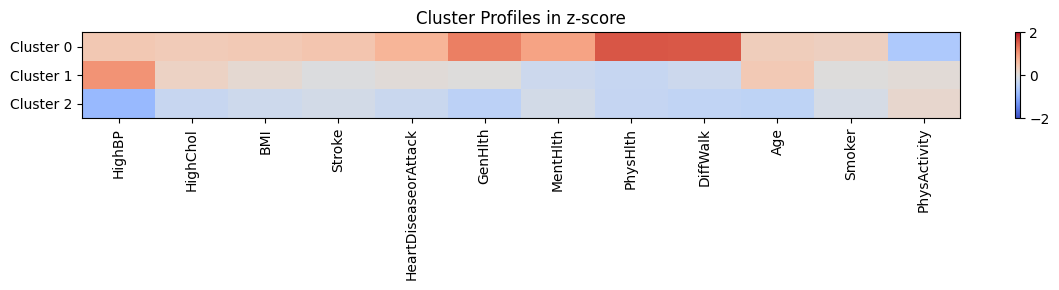

In [57]:
plt.figure(figsize=(12, 3))
plt.imshow(profile_z, cmap="coolwarm", vmin=-2, vmax=2, aspect="auto")
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(best_k), ["Cluster 0", "Cluster 1", "Cluster 2"])
plt.title("Cluster Profiles in z-score")
plt.tight_layout()
plt.show()

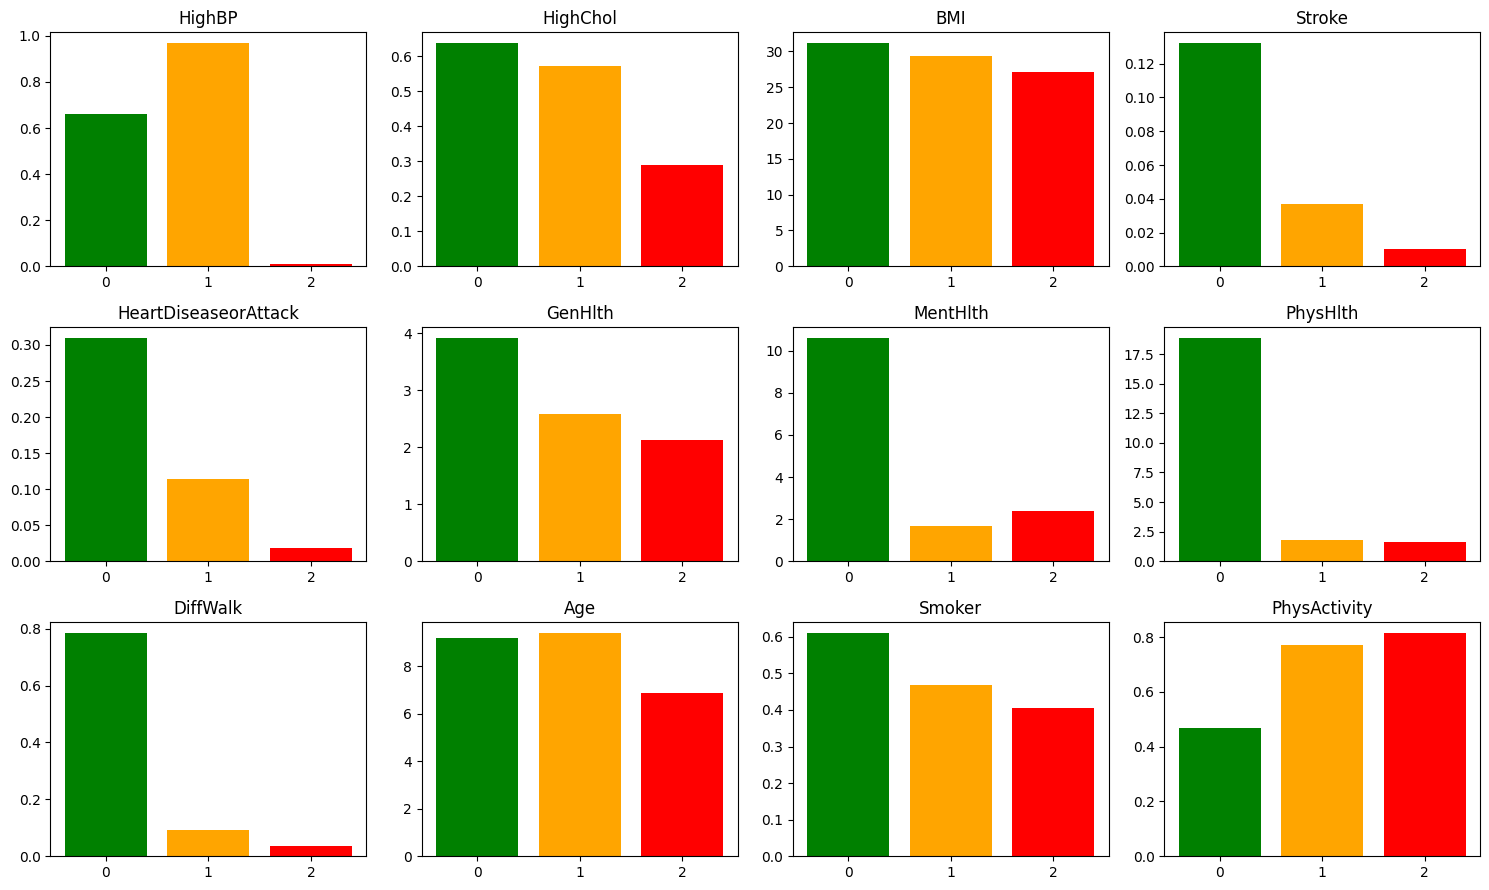

In [58]:
plt.figure(figsize=(15, 9))
for i in range(len(features)):
    plt.subplot(3, 4, i + 1)
    plt.bar(["0", "1", "2"], profile[features[i]], color=colors)
    plt.title(features[i])
plt.tight_layout()
plt.show()

In [59]:
# GenHlth is 1 for excellent and 5 for poor, so sorting by it gives the
# healthiest cluster first and that is how the tiers are named
order = profile["GenHlth"].sort_values().index
tiers = ["Low Risk", "Moderate Risk", "High Risk"]

cluster_risk = {}
for i in range(len(order)):
    cluster_risk[int(order[i])] = tiers[i]

print(profile["GenHlth"])
print(cluster_risk)

Cluster
0    3.908
1    2.589
2    2.126
Name: GenHlth, dtype: float64
{2: 'Low Risk', 1: 'Moderate Risk', 0: 'High Risk'}


In [60]:
# the diabetes column was never used for clustering. if the percentage still
# rises across the tiers then the clusters are clinically real
validation = df.groupby("Cluster")["Diabetes_012"].value_counts(normalize=True).unstack() * 100
validation.columns = ["No Diabetes %", "Prediabetes %", "Diabetes %"]
validation["Diabetes+Pre %"] = validation["Prediabetes %"] + validation["Diabetes %"]
validation = validation.round(2)
validation

,No Diabetes %,Prediabetes %,Diabetes %,Diabetes+Pre %
Cluster,,,,
0,64.03,3.14,32.83,35.97
1,76.87,2.64,20.49,23.13
2,93.88,0.98,5.14,6.12


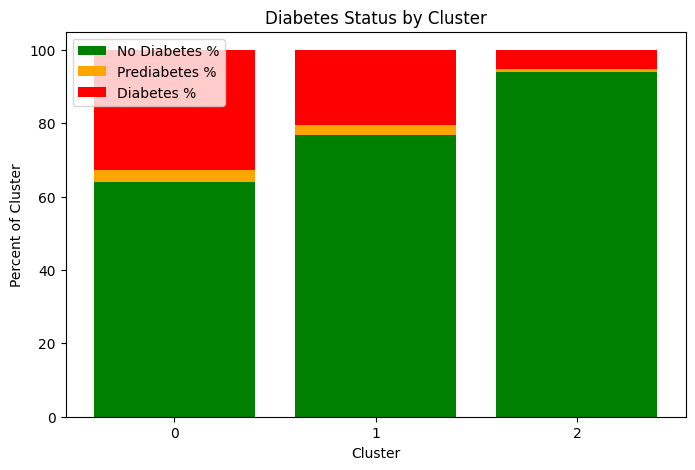

In [61]:
plt.figure(figsize=(8, 5))
bottom = np.zeros(best_k)
stack_cols = ["No Diabetes %", "Prediabetes %", "Diabetes %"]

for i in range(len(stack_cols)):
    plt.bar(["0", "1", "2"], validation[stack_cols[i]], bottom=bottom,
            color=colors[i], label=stack_cols[i])
    bottom = bottom + validation[stack_cols[i]].values
plt.xlabel("Cluster")
plt.ylabel("Percent of Cluster")
plt.title("Diabetes Status by Cluster")
plt.legend()
plt.show()

In [62]:
for c in range(best_k):
    print("Cluster", c, "-", cluster_risk[c])
    print("  Patients:", int(profile.loc[c, "n_patients"]))
    print("  Diabetes and Prediabetes:", validation.loc[c, "Diabetes+Pre %"], "%")
    print("  Mean BMI:", profile.loc[c, "BMI"])
    print("  High BP:", round(profile.loc[c, "HighBP"] * 100, 1), "%")
    print("  Heart disease:", round(profile.loc[c, "HeartDiseaseorAttack"] * 100, 1), "%")
    print("  Difficulty walking:", round(profile.loc[c, "DiffWalk"] * 100, 1), "%")
    print()

Cluster 0 - High Risk
  Patients: 1721
  Diabetes and Prediabetes: 35.97 %
  Mean BMI: 31.116
  High BP: 66.2 %
  Heart disease: 30.9 %
  Difficulty walking: 78.3 %

Cluster 1 - Moderate Risk
  Patients: 3377
  Diabetes and Prediabetes: 23.13 %
  Mean BMI: 29.312
  High BP: 96.7 %
  Heart disease: 11.4 %
  Difficulty walking: 9.2 %

Cluster 2 - Low Risk
  Patients: 4902
  Diabetes and Prediabetes: 6.12 %
  Mean BMI: 27.155
  High BP: 1.1 %
  Heart disease: 1.8 %
  Difficulty walking: 3.6 %



## 12. Final Conclusion

In [63]:
# one final table with everything a doctor would want to see
summary = pd.DataFrame()
summary["Risk Tier"] = [cluster_risk[c] for c in profile.index]
summary["Patients"] = profile["n_patients"]
summary["Diabetes+Pre %"] = validation["Diabetes+Pre %"]
summary["Mean BMI"] = profile["BMI"]
summary["HighBP %"] = (profile["HighBP"] * 100).round(1)
summary["DiffWalk %"] = (profile["DiffWalk"] * 100).round(1)
summary["Mean GenHlth"] = profile["GenHlth"]
summary

,Risk Tier,Patients,Diabetes+Pre %,Mean BMI,HighBP %,DiffWalk %,Mean GenHlth
0,High Risk,1721,35.97,31.116,66.2,78.3,3.908
1,Moderate Risk,3377,23.13,29.312,96.7,9.2,2.589
2,Low Risk,4902,6.12,27.155,1.1,3.6,2.126


### Conclusion

1. Three clustering algorithms were applied on the same 10000 patients and the same
   12 clinical features, and all three were checked with the silhouette score.
2. K-Means with k = 3 was selected. The other two scored higher but kept most of the
   patients in one cluster, so their groups were not useful.
3. The three clusters are Low Risk (4902 patients), Moderate Risk (3377) and
   High Risk (1721).
4. The diabetes column was never used while clustering, but the diabetes percentage
   still rises from 6.1 to 23.1 to 36.0 across the three tiers, so the clusters have
   real clinical meaning.
5. All the features come from a survey and basic measurements, so a clinic can sort
   its patients into these tiers without any blood test.

## Save the Model and Tables for the Streamlit App

In [64]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [65]:
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")

['models/pca.pkl']

In [66]:
metadata = {}
metadata["clinical_features"] = features
metadata["best_k"] = best_k
metadata["bmi_cap"] = [float(low), float(high)]
metadata["n_patients"] = len(df)
metadata["metrics"] = {"silhouette": float(kmeans_silhouette)}

metadata["cluster_risk"] = {}
for c in cluster_risk:
    metadata["cluster_risk"][str(c)] = cluster_risk[c]

In [67]:
metadata["algorithms"] = {}
metadata["algorithms"]["kmeans"] = {"k": best_k,
                                    "silhouette": float(kmeans_silhouette)}
metadata["algorithms"]["hierarchical"] = {"k": 3,
                                          "silhouette": float(hier_silhouette)}
metadata["algorithms"]["dbscan"] = {"eps": eps,
                                    "min_samples": min_samples,
                                    "n_clusters": n_dbscan_clusters,
                                    "noise": n_noise,
                                    "silhouette": float(dbscan_silhouette)}

In [68]:
# the app needs these to compare a new patient with the population
metadata["feature_ranges"] = {}
metadata["population_mean"] = {}
metadata["population_std"] = {}

for col in features:
    metadata["feature_ranges"][col] = [float(X[col].min()), float(X[col].max())]
    metadata["population_mean"][col] = float(X[col].mean())
    metadata["population_std"][col] = float(X[col].std())

In [69]:
with open("models/metadata.json", "w") as file:
    json.dump(metadata, file, indent=2)

In [70]:
profile.to_csv("models/cluster_profiles.csv")
profile_z.to_csv("models/cluster_profiles_z.csv")
validation.to_csv("models/cluster_validation.csv")
scores_table.to_csv("models/evaluation_scores.csv")
comparison.to_csv("models/algorithm_comparison.csv", index=False)

In [71]:
# the app plots these points, so the pca values are saved with the patients
clustered = df.copy()
clustered["PC1"] = points[:, 0]
clustered["PC2"] = points[:, 1]
clustered.to_csv("models/clustered_sample.csv", index=False)

In [72]:
profile.to_csv("outputs/cluster_profiles.csv")
scores_table.to_csv("outputs/evaluation_scores.csv")
summary.to_csv("outputs/healthcare_insights.csv")

print(sorted(os.listdir("models")))

['algorithm_comparison.csv', 'cluster_profiles.csv', 'cluster_profiles_z.csv', 'cluster_validation.csv', 'clustered_sample.csv', 'evaluation_scores.csv', 'kmeans_model.pkl', 'metadata.json', 'pca.pkl', 'scaler.pkl']


In [73]:
# load the saved files again and check one patient gets the same cluster
saved_model = joblib.load("models/kmeans_model.pkl")
saved_scaler = joblib.load("models/scaler.pkl")

prediction = saved_model.predict(saved_scaler.transform(X.iloc[[0]]))[0]

print("Saved model says:", prediction)
print("Training label was:", df.loc[0, "Cluster"])
print("Risk tier:", cluster_risk[prediction])

Saved model says: 0
Training label was: 0
Risk tier: High Risk
